# NB4 — Grad-CAM Visualization
## BioViT — Best Model Explainability on IU Chest X-Ray

Shows **where** the model looks on the X-ray when predicting each disease.

**Pipeline:**
```
Random X-ray → BioViT → Grad-CAM Heatmap → Overlay on X-ray
```

## Step 1 — Imports & Config

In [1]:
import warnings
warnings.filterwarnings('ignore')

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import torch
import torch.nn as nn
import timm
import albumentations as A
from albumentations.pytorch import ToTensorV2
from pathlib import Path
from sklearn.model_selection import train_test_split

DEVICE      = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
IMG_SIZE    = 224
SEED        = 42
NUM_CLASSES = 14
SAVE_DIR    = Path('gradcam_outputs')
SAVE_DIR.mkdir(exist_ok=True)

LABELS = [
    'Atelectasis', 'Cardiomegaly', 'Effusion', 'Infiltration',
    'Mass', 'Nodule', 'Pneumonia', 'Pneumothorax',
    'Consolidation', 'Edema', 'Emphysema', 'Fibrosis',
    'Pleural_Thickening', 'Hernia'
]

LABEL_KEYWORDS = {
    'Atelectasis'        : ['atelectasis', 'atelectatic'],
    'Cardiomegaly'       : ['cardiomegaly', 'cardiac enlargement', 'enlarged heart'],
    'Effusion'           : ['effusion', 'pleural fluid'],
    'Infiltration'       : ['infiltration', 'infiltrate'],
    'Mass'               : ['mass', 'tumor', 'tumour'],
    'Nodule'             : ['nodule', 'nodular'],
    'Pneumonia'          : ['pneumonia', 'pneumonic'],
    'Pneumothorax'       : ['pneumothorax'],
    'Consolidation'      : ['consolidation', 'consolidative'],
    'Edema'              : ['edema', 'oedema', 'pulmonary edema'],
    'Emphysema'          : ['emphysema', 'emphysematous'],
    'Fibrosis'           : ['fibrosis', 'fibrotic'],
    'Pleural_Thickening' : ['pleural thickening', 'pleural scarring'],
    'Hernia'             : ['hernia'],
}

print(f'Device     : {DEVICE}')
print(f'Save Dir   : {SAVE_DIR.resolve()}')
print(f'Classes    : {NUM_CLASSES}')

Device     : cuda
Save Dir   : D:\Projects\ScratchRadiology\gradcam_outputs
Classes    : 14


## Step 2 — Load BioViT (Best Model)

In [2]:
PRETRAIN_DIR = Path('ScratchCnnModels')

class BioViT(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.vit      = timm.create_model('vit_base_patch16_224', pretrained=False)
        in_feats      = self.vit.head.in_features
        self.vit.head = nn.Identity()
        self.head     = nn.Sequential(
            nn.LayerNorm(in_feats),
            nn.Linear(in_feats, num_classes)
        )

    def forward(self, x):
        return self.head(self.vit(x))

model = BioViT(num_classes=NUM_CLASSES)
ckpt  = torch.load(PRETRAIN_DIR / 'BioViT.pth', map_location=DEVICE)
model.load_state_dict(ckpt['model_state_dict'])
model = model.to(DEVICE)
model.eval()

print(' BioViT loaded successfully')

 BioViT loaded successfully


## Step 3 — Load Validation Data

In [3]:
df = pd.read_csv('preprocessed_df.csv')

# Extract labels
def extract_labels(row):
    text = ' '.join([
        str(row.get('findings_clean', '')),
        str(row.get('impression_clean', ''))
    ]).lower()
    return [int(any(kw in text for kw in kws))
            for kws in LABEL_KEYWORDS.values()]

label_array = np.array(df.apply(extract_labels, axis=1).tolist(), dtype=np.float32)
for i, lbl in enumerate(LABELS):
    df[lbl] = label_array[:, i]

# Same split as NB3
idx_all  = np.arange(len(df))
idx_train, idx_tmp = train_test_split(idx_all, test_size=0.2,  random_state=SEED)
idx_val,  idx_test = train_test_split(idx_tmp,  test_size=0.5,  random_state=SEED)
val_df = df.iloc[idx_val].reset_index(drop=True)

# Keep only rows with existing frontal image
val_df = val_df[val_df['frontal_path'].apply(lambda p: Path(p).exists())].reset_index(drop=True)

print(f'Validation samples with images: {len(val_df)}')

Validation samples with images: 334


## Step 4 — Grad-CAM for Vision Transformer

In [4]:
class ViTGradCAM:
    """
    Grad-CAM for Vision Transformer.
    Hooks into the last attention block to extract attention rollout + gradients.
    """
    def __init__(self, model):
        self.model      = model
        self.gradients  = None
        self.activations = None

        # Hook into last transformer block
        target_layer = model.vit.blocks[-1].norm1

        target_layer.register_forward_hook(self._save_activation)
        target_layer.register_full_backward_hook(self._save_gradient)

    def _save_activation(self, module, input, output):
        self.activations = output.detach()

    def _save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0].detach()

    def generate(self, img_tensor, class_idx):
        self.model.zero_grad()
        output = self.model(img_tensor)          # (1, 14)
        score  = output[0, class_idx]
        score.backward()

        # activations & gradients shape: (1, num_patches+1, hidden_dim)
        grads = self.gradients[0]                # (num_patches+1, hidden_dim)
        acts  = self.activations[0]              # (num_patches+1, hidden_dim)

        # Skip CLS token (index 0), use patch tokens
        grads = grads[1:]                        # (196, 768)
        acts  = acts[1:]                         # (196, 768)

        # Weight activations by mean gradient
        weights = grads.mean(dim=-1)             # (196,)
        cam     = (weights * acts.mean(dim=-1))  # (196,)
        cam     = torch.relu(cam)

        # Reshape to 14x14 (for 224x224 with 16x16 patches)
        n_patches = int(cam.shape[0] ** 0.5)
        cam = cam.reshape(n_patches, n_patches).cpu().numpy()

        # Resize to image size
        cam = cv2.resize(cam, (IMG_SIZE, IMG_SIZE))

        # Normalize
        if cam.max() > cam.min():
            cam = (cam - cam.min()) / (cam.max() - cam.min())

        return cam


def overlay_heatmap(img_bgr, cam, alpha=0.45):
    """Overlay Grad-CAM heatmap on original image."""
    heatmap = cv2.applyColorMap(np.uint8(255 * cam), cv2.COLORMAP_JET)
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    overlay = (alpha * heatmap + (1 - alpha) * img_rgb).astype(np.uint8)
    return overlay


# Transform for inference
infer_transform = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.Normalize(mean=[0.485, 0.456, 0.406],
                std =[0.229, 0.224, 0.225]),
    ToTensorV2(),
])

gradcam = ViTGradCAM(model)
print(' Grad-CAM ready')

 Grad-CAM ready


## Step 5 — Generate Grad-CAM for 6 Random Samples

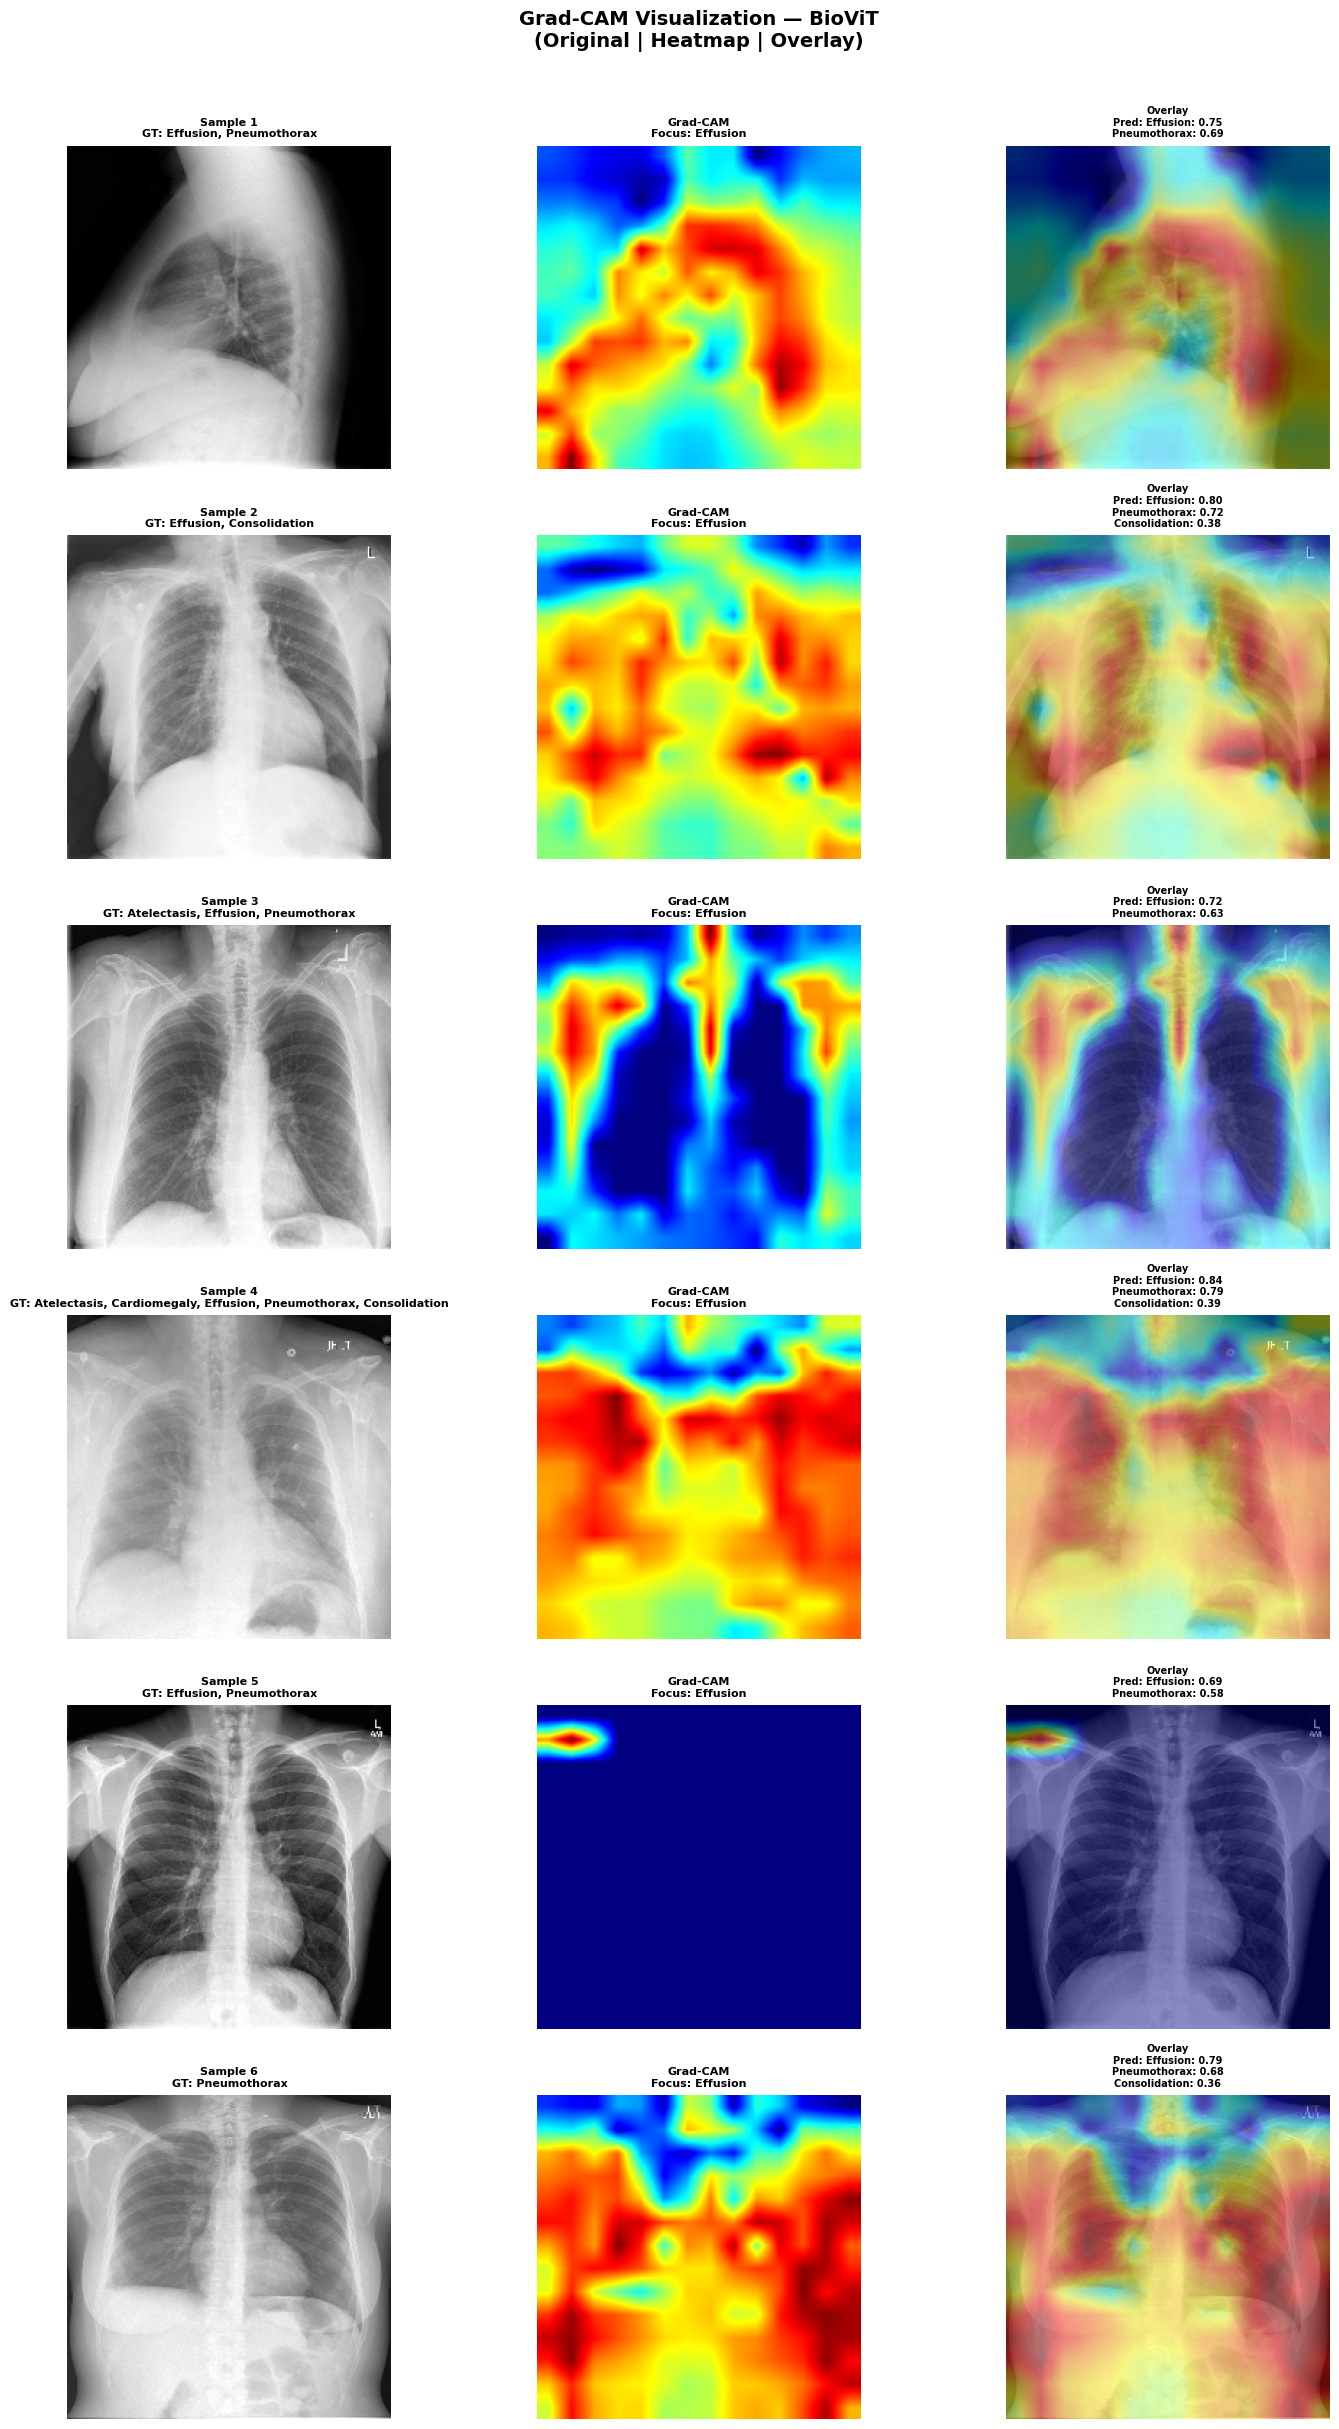

Saved → gradcam_outputs\gradcam_random_samples.png


In [5]:
N_SAMPLES  = 6
THRESHOLD  = 0.3          # prediction confidence threshold

np.random.seed(SEED)
sample_indices = np.random.choice(len(val_df), N_SAMPLES, replace=False)

fig, axes = plt.subplots(N_SAMPLES, 3, figsize=(15, N_SAMPLES * 4))
fig.suptitle('Grad-CAM Visualization — BioViT\n'
             '(Original | Heatmap | Overlay)',
             fontsize=14, fontweight='bold', y=1.01)

for row_idx, sample_idx in enumerate(sample_indices):
    row    = val_df.iloc[sample_idx]
    img_path = row['frontal_path']

    # ── Load & preprocess image ───────────────────────────────────────────
    img_bgr = cv2.imread(str(img_path))
    img_bgr = cv2.resize(img_bgr, (IMG_SIZE, IMG_SIZE))
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

    augmented  = infer_transform(image=img_rgb)
    img_tensor = augmented['image'].unsqueeze(0).to(DEVICE)  # (1,3,224,224)

    # ── Run model ────────────────────────────────────────────────────────
    with torch.no_grad():
        logits = model(img_tensor)
        probs  = torch.sigmoid(logits)[0].cpu().numpy()

    # ── Pick top predicted class for Grad-CAM ────────────────────────────
    top_class_idx = int(np.argmax(probs))

    # ── Generate Grad-CAM ─────────────────────────────────────────────────
    img_tensor.requires_grad = True
    cam     = gradcam.generate(img_tensor, top_class_idx)
    overlay = overlay_heatmap(img_bgr, cam)

    # ── Build label strings ───────────────────────────────────────────────
    predicted = [(LABELS[i], probs[i]) for i in range(NUM_CLASSES)
                 if probs[i] >= THRESHOLD]
    predicted.sort(key=lambda x: x[1], reverse=True)
    pred_str  = '\n'.join([f'{l}: {p:.2f}' for l, p in predicted[:4]])
    if not pred_str:
        pred_str = 'No finding (all < threshold)'

    gt_labels = [LABELS[i] for i in range(NUM_CLASSES) if row[LABELS[i]] == 1]
    gt_str    = ', '.join(gt_labels) if gt_labels else 'Normal'

    # ── Plot ──────────────────────────────────────────────────────────────
    ax_orig    = axes[row_idx][0]
    ax_heat    = axes[row_idx][1]
    ax_overlay = axes[row_idx][2]

    # Heatmap (standalone)
    heatmap_img = cv2.applyColorMap(np.uint8(255 * cam), cv2.COLORMAP_JET)
    heatmap_img = cv2.cvtColor(heatmap_img, cv2.COLOR_BGR2RGB)

    ax_orig.imshow(img_rgb, cmap='gray')
    ax_orig.set_title(f'Sample {row_idx+1}\nGT: {gt_str}',
                      fontsize=8, fontweight='bold')
    ax_orig.axis('off')

    ax_heat.imshow(heatmap_img)
    ax_heat.set_title(f'Grad-CAM\nFocus: {LABELS[top_class_idx]}',
                      fontsize=8, fontweight='bold')
    ax_heat.axis('off')

    ax_overlay.imshow(overlay)
    ax_overlay.set_title(f'Overlay\nPred: {pred_str}',
                         fontsize=7, fontweight='bold')
    ax_overlay.axis('off')

plt.tight_layout()
out_path = SAVE_DIR / 'gradcam_random_samples.png'
plt.savefig(out_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved → {out_path}')

## Step 6 — Per-Class Grad-CAM (Top Predicted Disease)

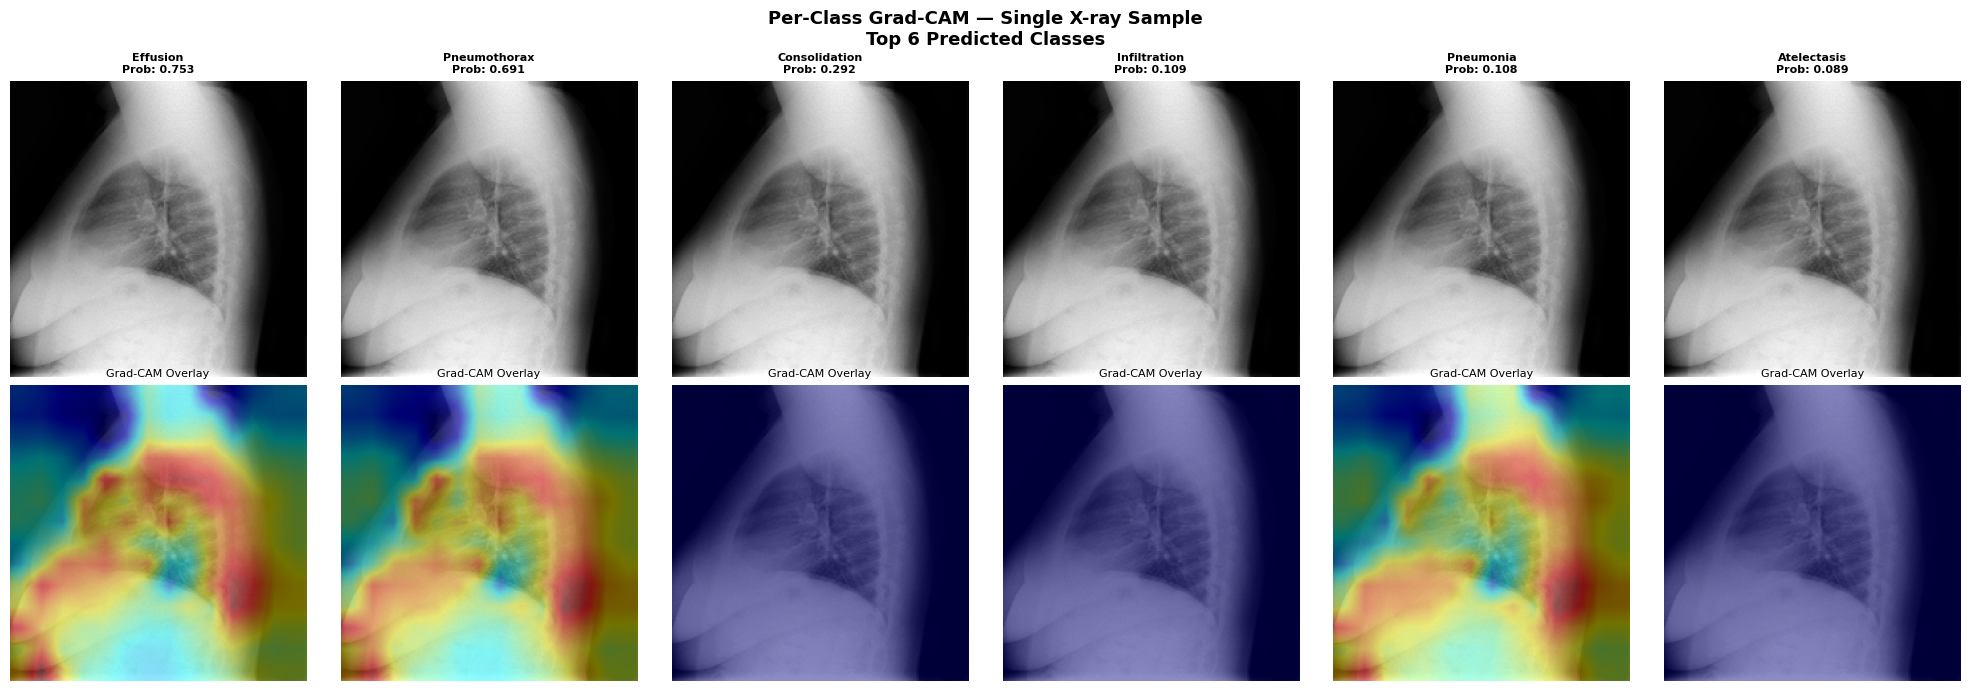

Saved → gradcam_outputs\gradcam_per_class.png


In [6]:
# Pick 1 sample and show Grad-CAM for every predicted disease
sample_row = val_df.iloc[sample_indices[0]]
img_path   = sample_row['frontal_path']

img_bgr = cv2.imread(str(img_path))
img_bgr = cv2.resize(img_bgr, (IMG_SIZE, IMG_SIZE))
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

augmented  = infer_transform(image=img_rgb)
img_tensor = augmented['image'].unsqueeze(0).to(DEVICE)

with torch.no_grad():
    logits = model(img_tensor)
    probs  = torch.sigmoid(logits)[0].cpu().numpy()

# Top 6 predicted classes
top6_idx = np.argsort(probs)[::-1][:6]

fig, axes = plt.subplots(2, 6, figsize=(20, 7))
fig.suptitle('Per-Class Grad-CAM — Single X-ray Sample\n'
             'Top 6 Predicted Classes',
             fontsize=13, fontweight='bold')

for col, cls_idx in enumerate(top6_idx):
    img_tensor_grad = augmented['image'].unsqueeze(0).to(DEVICE)
    img_tensor_grad.requires_grad = True

    cam     = gradcam.generate(img_tensor_grad, cls_idx)
    overlay = overlay_heatmap(img_bgr, cam)

    axes[0][col].imshow(img_rgb, cmap='gray')
    axes[0][col].set_title(f'{LABELS[cls_idx]}\nProb: {probs[cls_idx]:.3f}',
                            fontsize=8, fontweight='bold')
    axes[0][col].axis('off')

    axes[1][col].imshow(overlay)
    axes[1][col].set_title('Grad-CAM Overlay', fontsize=8)
    axes[1][col].axis('off')

plt.tight_layout()
out_path2 = SAVE_DIR / 'gradcam_per_class.png'
plt.savefig(out_path2, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved → {out_path2}')

## Step 7 — Saved Files

| File | Description |
|------|-------------|
| `gradcam_outputs/gradcam_random_samples.png` | 6 random samples with heatmap + overlay |
| `gradcam_outputs/gradcam_per_class.png` | Per-class Grad-CAM for 1 sample |